In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df = pd.read_csv('/content/sample_data/california_housing_train.csv')

drop_columns = [
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality',
    'Locality Verbose',
    'Rating text'
]

for col in drop_columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

df.fillna(method='ffill', inplace=True)

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("========== Linear Regression ==========")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

print("\n========== Decision Tree ==========")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("\n========== Random Forest ==========")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

print("\nModel Comparison Completed Successfully!")

/tmp/ipykernel_6845/718560084.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


========== Linear Regression ==========
MAE : 49983.47465122931
MSE : 4634658406.223264
RMSE: 68078.32552452553
R2 Score: 0.6636396350243869

========== Decision Tree ==========
MAE : 44566.22352941176
MSE : 4843750289.105883
RMSE: 69597.05661237321
R2 Score: 0.6484647902191261

========== Random Forest ==========
MAE : 32359.7915
MSE : 2441797346.976846
RMSE: 49414.54590479251
R2 Score: 0.822786541134775

Model Comparison Completed Successfully!


Top 10 Cuisines by Average Rating:

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


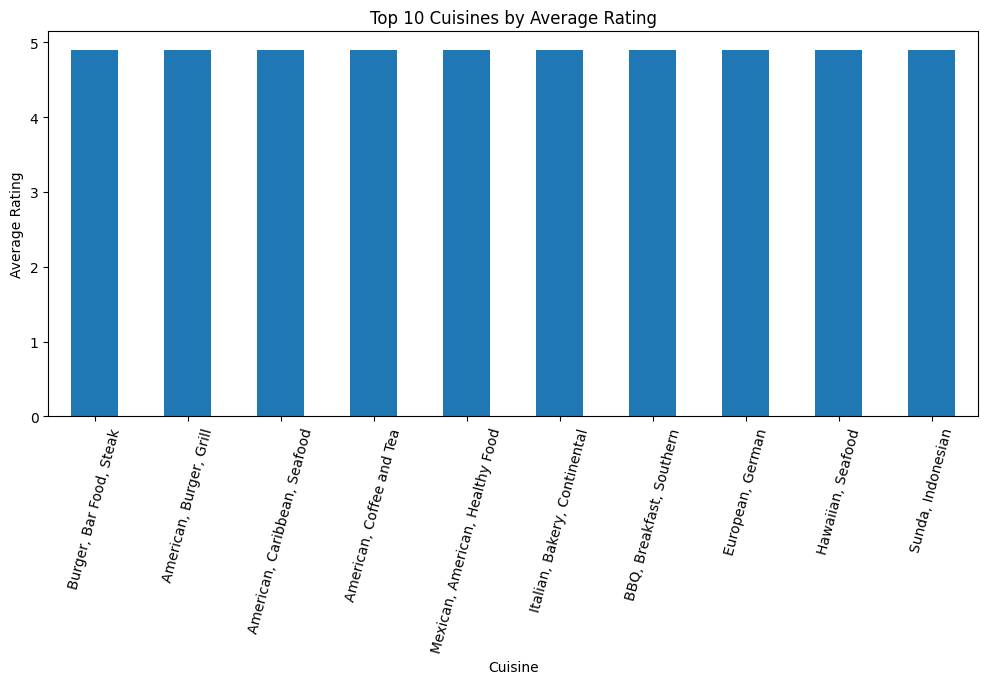


Top 10 Most Popular Cuisines (Based on Votes):

Cuisines
North Indian, Mughlai             53747
North Indian                      46241
North Indian, Chinese             42012
Cafe                              30657
Chinese                           21925
North Indian, Mughlai, Chinese    20115
Fast Food                         17852
South Indian                      16433
Mughlai, North Indian             15275
Italian                           14799
Name: Votes, dtype: int64


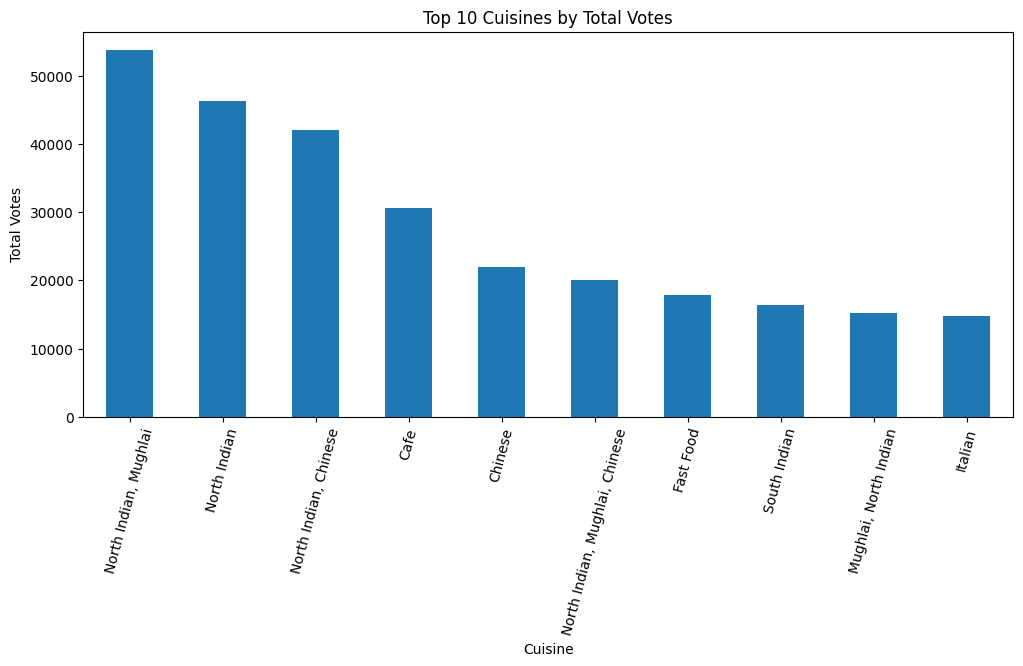


Highest Rated Cuisines:

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


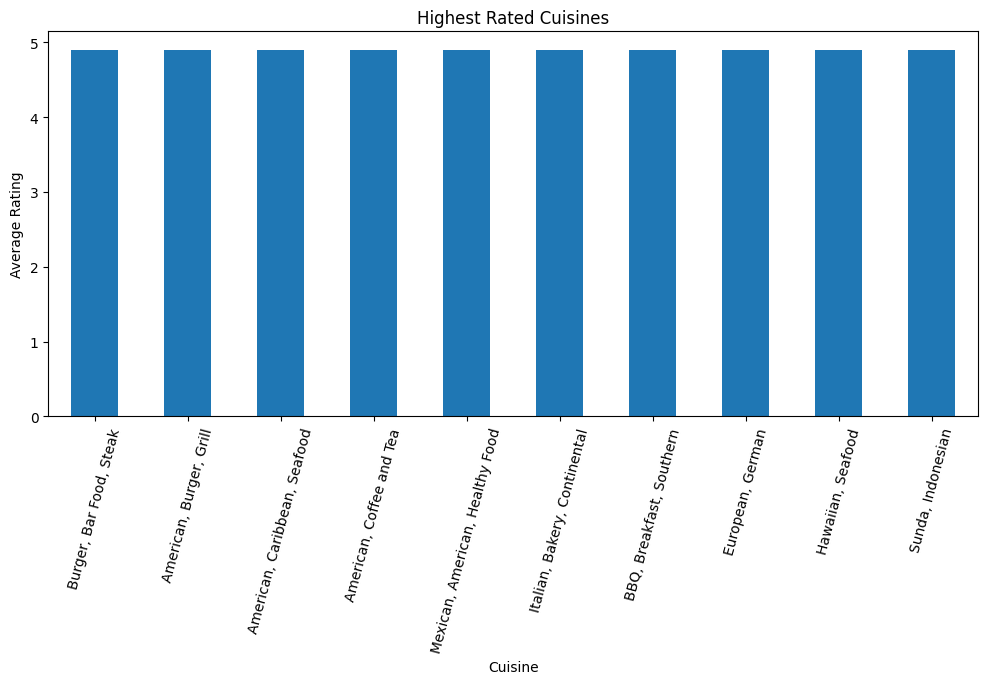


Customer Preference Analysis Completed Successfully!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Dataset .csv")

cuisine_rating = (
    df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Cuisines by Average Rating:\n")
print(cuisine_rating)

plt.figure(figsize=(12,5))
cuisine_rating.plot(kind="bar")
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=75)
plt.show()

cuisine_votes = (
    df.groupby("Cuisines")["Votes"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Most Popular Cuisines (Based on Votes):\n")
print(cuisine_votes)

plt.figure(figsize=(12,5))
cuisine_votes.plot(kind="bar")
plt.title("Top 10 Cuisines by Total Votes")
plt.xlabel("Cuisine")
plt.ylabel("Total Votes")
plt.xticks(rotation=75)
plt.show()

highest_rated = (
    df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nHighest Rated Cuisines:\n")
print(highest_rated)

plt.figure(figsize=(12,5))
highest_rated.plot(kind="bar")
plt.title("Highest Rated Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=75)
plt.show()

print("\nCustomer Preference Analysis Completed Successfully!")

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving Dataset .csv to Dataset .csv
User uploaded file "Dataset .csv" with length 2249716 bytes


Once the file is uploaded, you can re-run the previous cell (`KisOx-8NDCr1`) to load the `Dataset.csv` and proceed with the analysis.

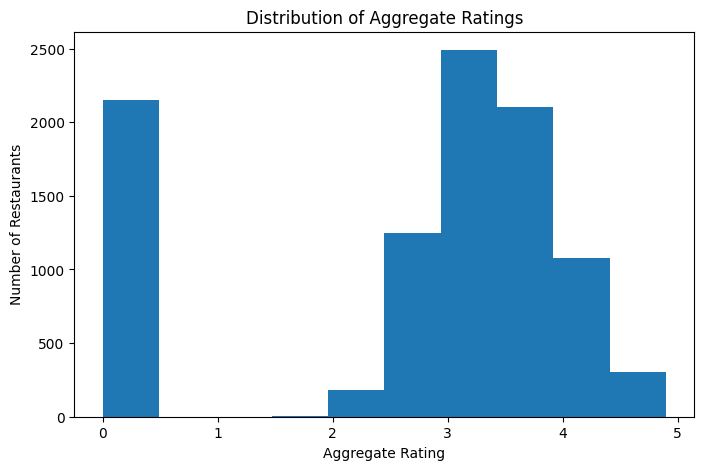

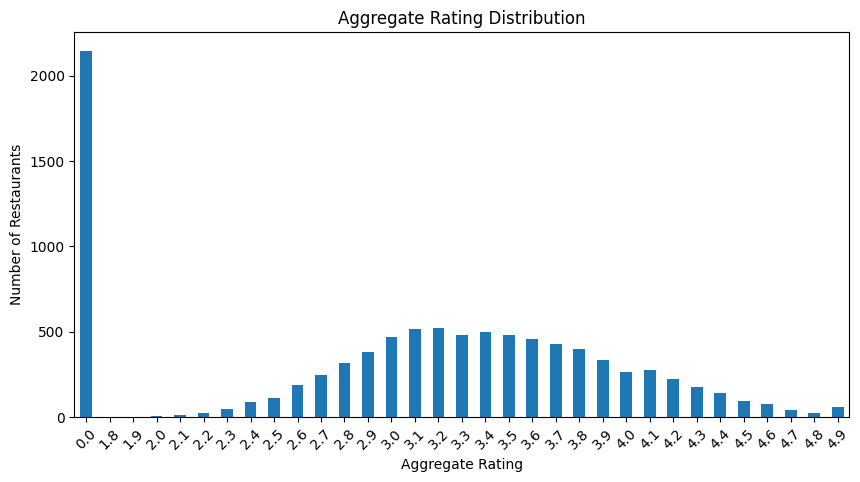

Top 10 Cuisines by Average Rating:
Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


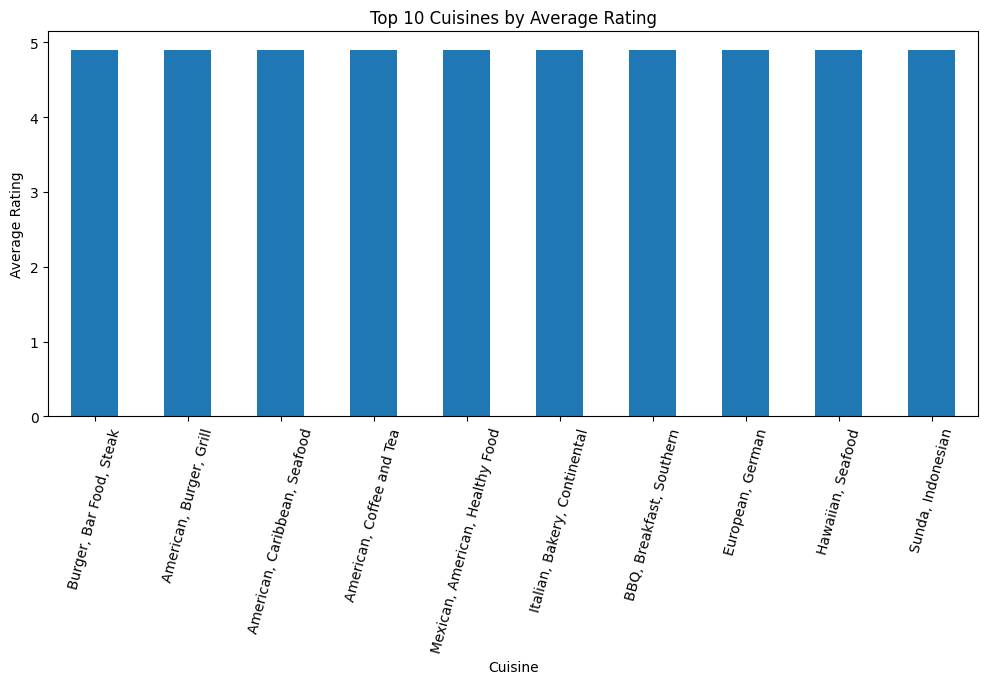


Top 10 Cities by Average Rating:
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


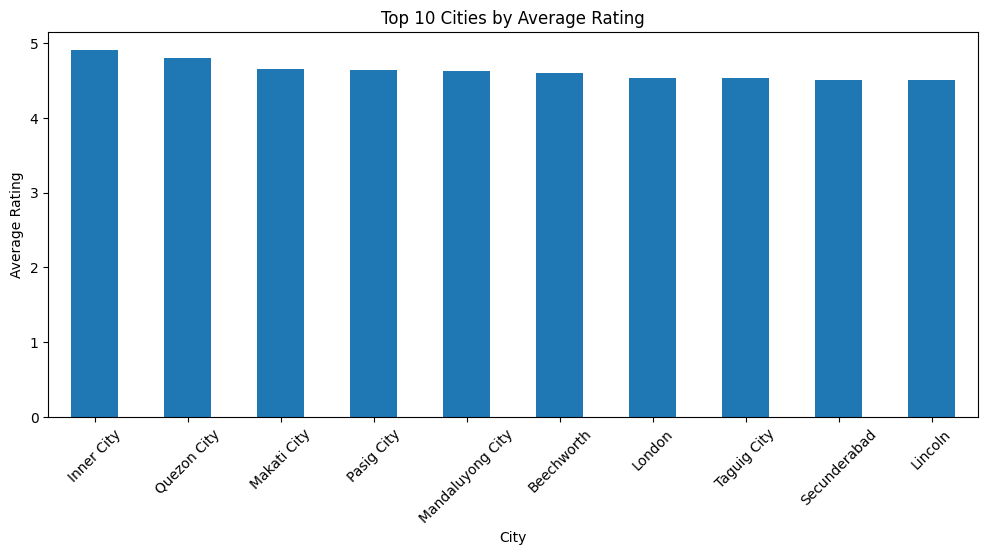

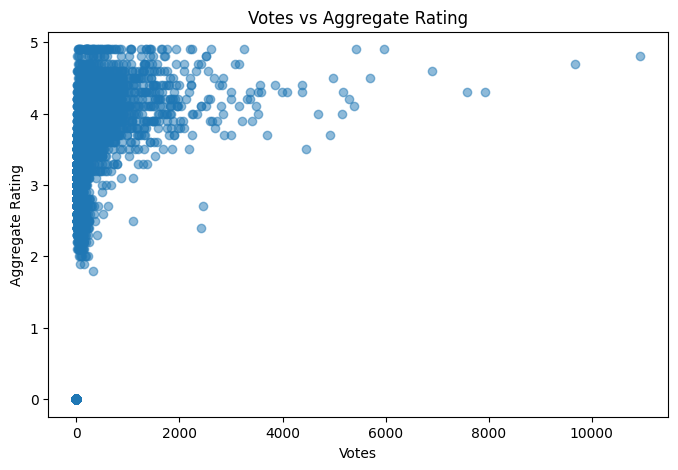


Average Rating by Price Range:
Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


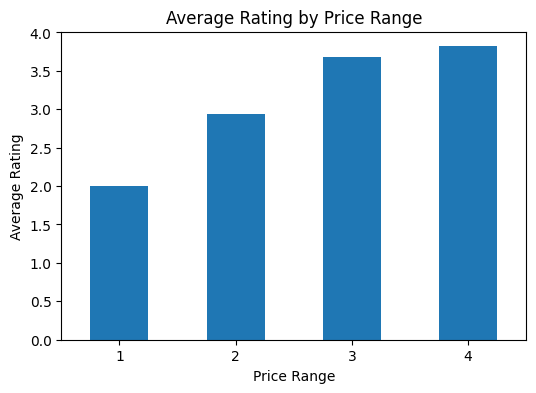


Data Visualization Completed Successfully!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Dataset .csv")

plt.figure(figsize=(8,5))
plt.hist(df["Aggregate rating"], bins=10)
plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.show()

rating_counts = df["Aggregate rating"].value_counts().sort_index()

plt.figure(figsize=(10,5))
rating_counts.plot(kind="bar")
plt.title("Aggregate Rating Distribution")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.show()

top_cuisines = (
    df.groupby("Cuisines")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Cuisines by Average Rating:")
print(top_cuisines)

plt.figure(figsize=(12,5))
top_cuisines.plot(kind="bar")
plt.title("Top 10 Cuisines by Average Rating")
plt.xlabel("Cuisine")
plt.ylabel("Average Rating")
plt.xticks(rotation=75)
plt.show()

top_cities = (
    df.groupby("City")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Cities by Average Rating:")
print(top_cities)

plt.figure(figsize=(12,5))
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Votes"], df["Aggregate rating"], alpha=0.5)
plt.title("Votes vs Aggregate Rating")
plt.xlabel("Votes")
plt.ylabel("Aggregate Rating")
plt.show()
price_rating = df.groupby("Price range")["Aggregate rating"].mean()

print("\nAverage Rating by Price Range:")
print(price_rating)

plt.figure(figsize=(6,4))
price_rating.plot(kind="bar")
plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.show()

print("\nData Visualization Completed Successfully!")